# Model with Cosine Loss

# Table of Contents
1. [Loading Data](#Loading-Data)
2. [Labels](#Labels)
3. [Data Processing](#Data-Processing)
4. [Building Model](#Building-Model)
5. [Visualizations](#visualizations)
6. [Evaluation](#Evaluation)

## Loading Data

In [1]:
import pandas as pd
import zipfile
import chardet
import io


zip_path = 'v2_combined-20260406T063631Z-1-001.zip'


data_dict = {}

with zipfile.ZipFile(zip_path, 'r') as z:
   
    files = z.namelist()
    
    for file_name in files:
        if file_name.endswith('.csv'):
            with z.open(file_name) as f:
               
                raw_data = f.read(20000) 
                result = chardet.detect(raw_data)
                enc = result['encoding']
                
                
                f.seek(0)
                print(f"Loading {file_name} with detected encoding: {enc}")
                
                try:
                    
                    data_dict[file_name] = pd.read_csv(f, encoding=enc)
                except Exception as e:
                    print(f"Failed with {enc}, trying 'latin1' fallback for {file_name}")
                    f.seek(0)
                    data_dict[file_name] = pd.read_csv(f, encoding='latin1')

# To check if it worked, print the keys (filenames)
print("\nSuccessfully loaded DataFrames:", list(data_dict.keys()))

Loading v2_combined/data_chunk_4.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_1.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_0.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_6.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_14.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_14.csv
Loading v2_combined/Reviews/reviews_chunk_10.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_10.csv
Loading v2_combined/Reviews/reviews_chunk_3.csv with detected encoding: Windows-1252
Failed with Windows-1252, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_3.csv
Loading v2_combined/data_chunk_7.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_2.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_5.csv with detected encoding: ascii
Fail

In [2]:
data_keys = [k for k in data_dict.keys() if 'data_chunk' in k]
review_keys = [k for k in data_dict.keys() if 'reviews_chunk' in k]



df_main_data = pd.concat([data_dict[k] for k in data_keys], axis=0, ignore_index=True).drop_duplicates()


df_reviews = pd.concat([data_dict[k] for k in review_keys], axis=0, ignore_index=True).drop_duplicates()

print(f"Main Data Rows: {len(df_main_data)}")
print(f"Review Rows: {len(df_reviews)}")

Main Data Rows: 572215
Review Rows: 3794003


In [3]:
df_main_data = df_main_data.rename(columns={'RecipeId': 'recipe_id'})

In [4]:
df_main_data

,recipe_id,Name,RecipeInstructions,Images,AggregatedRating_na,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,...,WHO_Fat_Compliant,WHO_Sodium_Compliant,WHO_Score,WHO_Healthy,Energy_kJ,A_score,C_score,FSA_Score,FSA_Healthy,popularity_score
0,255671,Homemade Candy Corn,"['Combine sugar, butter, and corn syrup in pan...",[],0.000000,0.0,1914.40000,42.000000,26.300000,116.50000,...,True,False,1,False,8009.849600,38,4,34,False,0.000000
1,255672,The Dom's Antipasto Salad (With Pasta),['In a large bowl toss the cooked penne with t...,['https://img.sndimg.com/food/image/upload/w_5...,5.000000,4.0,371.80000,26.100000,9.500000,44.50000,...,False,False,0,False,1555.611200,21,8,13,False,8.047190
2,255673,Basically Bittersweet Mocha Cake,"['Pre-heat oven to 350 degrees (F).', 'Mix all...",[],5.000000,1.0,127.00000,3.200000,0.400000,17.80000,...,True,True,3,True,531.368000,4,4,0,True,3.465736
3,255674,Pumpkin Dip,"[""In a medium bowl, blend cream cheese and con...",[],4.500000,3.0,232.60000,9.900000,5.600000,31.20000,...,False,True,1,False,973.198400,15,1,14,False,6.238325
4,255675,Vegan Pumpkin Scones With Maple Brown Sugar Glaze,"['In a large mixing bowl, combine dry ingredie...",[],3.500000,2.0,204.10000,5.800000,1.000000,0.00000,...,True,True,3,True,853.954400,6,1,5,False,3.845143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572210,222886,Grateful Dead Cocktail,"Combine tequila, vodka, rum, gin, and raspberr...",https://images.media-allrecipes.com/userphotos...,3.500000,4.0,403.19880,0.090000,0.001800,0.00000,...,True,True,3,True,1686.983779,9,0,9,False,5.633033
572211,25650,Cheese Filling For Pastries,Sprinkle raisins with brandy and set aside.\nI...,https://images.media-allrecipes.com/userphotos...,4.333333,3.0,115.52360,8.783111,5.451905,39.03119,...,False,True,1,False,483.350742,7,1,6,False,6.007276
572212,23544,Peach Smoothie,"In a blender, combine peaches, ice cream, soy ...",https://images.media-allrecipes.com/userphotos...,3.615385,21.0,151.52430,4.243811,1.667471,9.24000,...,True,True,3,True,633.977671,6,4,2,True,11.175307
572213,170710,Double Dare Peaches,Melt the butter in a large skillet over medium...,https://images.media-allrecipes.com/userphotos...,4.714286,19.0,402.52910,21.624480,12.901280,74.17906,...,False,True,1,False,1684.181754,26,4,22,False,14.122738


In [5]:
import kagglehub

path = kagglehub.dataset_download("elisaxxygao/foodrecsysv1")
IMG_DIR = f"{path}/raw-data-images/raw-data-images"

df_kaggle_lookup = pd.read_csv(f"{path}/core-data_recipe.csv")[['recipe_id']]
df_kaggle_lookup['image_path'] = df_kaggle_lookup['recipe_id'].apply(lambda x: f"{IMG_DIR}/{x}.jpg")



final_recipe_df = pd.merge(
    df_main_data, 
    df_kaggle_lookup, 
    on='recipe_id', 
    how='inner'
)


print(f"Total recipes with images and metadata: {len(final_recipe_df)}")

Total recipes with images and metadata: 89937


## Label

In [6]:
vocab_df  = pd.read_csv('ingredient_counts_ingredients_canonical_final_le_5_replace.csv')
label_col = vocab_df.columns[0]  # ingredients_canonical_final
vocab     = {ing: idx for idx, ing in enumerate(vocab_df[label_col])}

print(f"Vocab size: {len(vocab)}")
print(f"Top 10: {list(vocab.keys())[:10]}")

Vocab size: 5442
Top 10: ['salt', 'onion', 'sugar', 'butter', 'garlic', 'egg', 'olive oil', 'water', 'milk', 'flour']


## Data Processing

In [7]:
import os, re, pickle, torch, requests
import torch.nn as nn
import pandas as pd
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
import kagglehub

In [8]:
train_df, temp_df = train_test_split(
    final_recipe_df, 
    test_size=0.4, 
    random_state=42, 
    shuffle=True
)

# 2. Second split: Split the 40% Temp into two equal 20% halves
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    shuffle=True
)

# 3. Final Verification of the Chunks
print(f"Final Combined Dataset: {len(final_recipe_df)} rows")
print("-" * 30)
print(f"Train Set: {len(train_df)} rows (60%)")
print(f"Val Set:   {len(val_df)} rows (20%)")
print(f"Test Set:  {len(test_df)} rows (20%)")

Final Combined Dataset: 89937 rows
------------------------------
Train Set: 53962 rows (60%)
Val Set:   17987 rows (20%)
Test Set:  17988 rows (20%)


In [9]:
class RecipeDataset(Dataset):
    def __init__(self, df, vocab, transform=None):
        self.df        = df.reset_index(drop=True)
        self.vocab     = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        # Parse ingredients
        label = torch.zeros(len(self.vocab))
        try:
            ingredients = ast.literal_eval(row['ingredients_canonical_final'])
            for ing in ingredients:
                ing = ing.lower().strip()
                if ing in self.vocab:
                    label[self.vocab[ing]] = 1.0
        except:
            pass

        return image, label

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Resnet Params
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(RecipeDataset(train_df, vocab, train_transform), batch_size=8, shuffle=True,  num_workers=1)
val_loader   = DataLoader(RecipeDataset(val_df,   vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)
test_loader  = DataLoader(RecipeDataset(test_df,  vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

Train: 53962 | Val: 17987 | Test: 17988


In [10]:
vocab_df

,Ingredient,Count
0,salt,207585
1,onion,147344
2,sugar,136805
3,butter,135578
4,garlic,131991
...,...,...
5437,torn arugula leaf,6
5438,olive oil flavored vegetable cooking spray,6
5439,mccormick garlic powder,6
5440,fluid ounce whiskey,6


In [11]:
import ast
# Check val labels
for images, labels in val_loader:
    print(f"Label sum per sample: {labels.sum(dim=1)[:5]}")
    print(f"Max label value: {labels.max()}")
    break

# Check a sample from val_df
sample = val_df['ingredients_canonical_final'].iloc[0]
print(f"\nVal sample: {repr(sample)}")
parsed = ast.literal_eval(sample)
print(f"Parsed: {parsed[:3]}")

# Check matches
for ing in parsed[:5]:
    ing_clean = ing.lower().strip()
    print(f"  '{ing_clean}' in vocab: {ing_clean in vocab}")

Label sum per sample: tensor([10., 14.,  3.,  5.,  6.])
Max label value: 1.0

Val sample: "['all purpose flour', 'sugar', 'baking soda', 'salt', 'nutmeg', 'cinnamon', 'shortening', 'egg', 'banana', 'rolled oat']"
Parsed: ['all purpose flour', 'sugar', 'baking soda']
  'all purpose flour' in vocab: True
  'sugar' in vocab: True
  'baking soda' in vocab: True
  'salt' in vocab: True
  'nutmeg' in vocab: True


## Building Model

In [12]:
from tqdm import tqdm



def get_frozen_model(checkpoint_path):
    model = models.resnet50()
    ckpt  = torch.load(checkpoint_path, map_location='cpu', weights_only=False,encoding='latin1')
    
    # Load vision weights
    state_dict = {
        k.replace('visionMLP.module.', ''): v.float()
        for k, v in ckpt['state_dict'].items()
        if 'visionMLP' in k
    }
    model.load_state_dict(state_dict, strict=False)
    
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # New head 
    model.fc = nn.Linear(2048, len(vocab))
    return model

In [13]:
def cosine_loss(predictions, targets):
    # Normalize both vectors
    pred_norm   = torch.nn.functional.normalize(torch.sigmoid(predictions), p=2, dim=1)
    target_norm = torch.nn.functional.normalize(targets, p=2, dim=1)
    
    # Cosine similarity — 1 means identical, 0 means orthogonal
    cosine_sim  = (pred_norm * target_norm).sum(dim=1)
    
    # Loss = 1 - similarity (minimize loss = maximize similarity)
    return (1 - cosine_sim).mean()

def train_final_layer1(model, train_loader, val_loader, epochs=5):
    counts_tensor = torch.zeros(len(vocab))
    for ing, count in zip(vocab_df['Ingredient'], vocab_df['Count']):
        if ing in vocab:
            counts_tensor[vocab[ing]] = count

    pos_weight = torch.clamp(
        (len(train_df) - counts_tensor) / (counts_tensor + 1e-6),
        min=1.0, max=5.0
    )

    # Combined loss — BCE for binary predictions + cosine for similarity
    bce_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    def combined_loss(predictions, targets, alpha=0.5):
        bce  = bce_criterion(predictions, targets)
        cos  = cosine_loss(predictions, targets)
        return alpha * bce + (1 - alpha) * cos

    best_val_loss = float('inf')
    optimizer     = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = combined_loss(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += combined_loss(model(images), labels).item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save({
                'state_dict': model.state_dict(),
                'vocab':      vocab
            }, 'best_ingredient_model_cosine.pth')
            print(f"  ✓ Saved best model (Val Loss: {best_val_loss:.4f})")

    return train_losses, val_losses

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

resnet = get_frozen_model('model_e220_v-4.700.pth.tar').to(device)

train_losses,val_losses=train_final_layer1(resnet, train_loader, val_loader, epochs=8)

Using: cuda


Epoch 1: 100%|██████████| 6746/6746 [09:36<00:00, 11.71it/s]


Epoch 1/8 | Train: 0.4166 | Val: 0.4258
  ✓ Saved best model (Val Loss: 0.4258)


Epoch 2: 100%|██████████| 6746/6746 [08:51<00:00, 12.68it/s]


Epoch 2/8 | Train: 0.4189 | Val: 0.4170
  ✓ Saved best model (Val Loss: 0.4170)


...

Epoch 6/8 | Train: 0.3843 | Val: 0.3786
  ✓ Saved best model (Val Loss: 0.3786)


Epoch 7: 100%|██████████| 6746/6746 [08:59<00:00, 12.50it/s]


Epoch 7/8 | Train: 0.3766 | Val: 0.3772
  ✓ Saved best model (Val Loss: 0.3772)


Epoch 8: 100%|██████████| 6746/6746 [08:53<00:00, 12.65it/s]


Epoch 8/8 | Train: 0.3755 | Val: 0.3766
  ✓ Saved best model (Val Loss: 0.3766)


## Visualizations

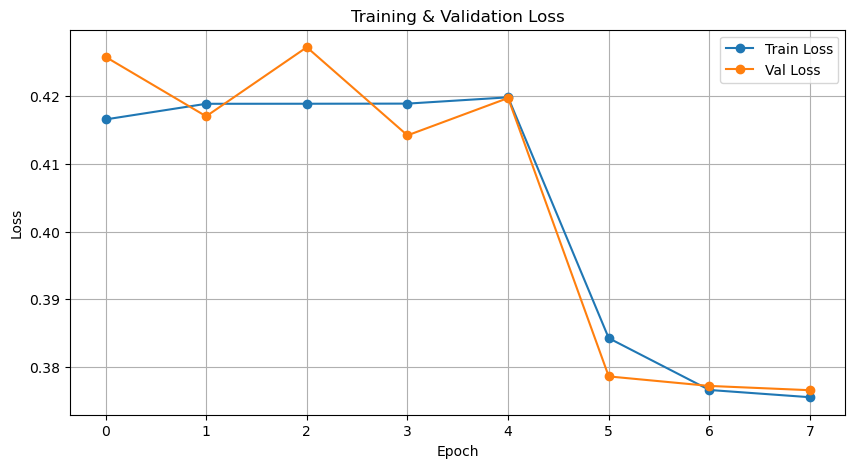

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()




In [13]:
import numpy as np
resnet = get_frozen_model('model_e220_v-4.700.pth.tar').to(device)
idx_to_ing = {v: k for k, v in vocab.items()}


NameError: name 'device' is not defined

## Evaluation

In [18]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
model = models.resnet50(weights=None) 


model.fc = nn.Linear(model.fc.in_features, len(vocab)) 


checkpoint = torch.load('best_ingredient_model_cosine.pth')
model.load_state_dict(checkpoint['state_dict'])
model.eval()
model.to(device)

all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        # Convert logits to probabilities, then to binary (0/1)
        
        preds = (torch.sigmoid(outputs) > 0.35).cpu().numpy()
        
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())


y_true = np.vstack(all_labels)
y_pred = np.vstack(all_preds)


precision = precision_score(y_true, y_pred, average='samples', zero_division=0)
recall = recall_score(y_true, y_pred, average='samples', zero_division=0)
f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)

print(f"--- Final Evaluation (Per-Recipe Average) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

--- Final Evaluation (Per-Recipe Average) ---
Precision: 0.1957
Recall:    0.2796
F1 Score:  0.2188


In [19]:
from sklearn.metrics import jaccard_score

model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        
        preds = (torch.sigmoid(outputs) > 0.3).cpu().numpy()
        test_preds.append(preds)
        test_labels.append(labels.cpu().numpy())

y_test_true = np.vstack(test_labels)
y_test_pred = np.vstack(test_preds)


final_test_jaccard = jaccard_score(y_test_true, y_test_pred, average='samples')
print(f"Final Test Jaccard Similarity: {final_test_jaccard:.4f}")

Final Test Jaccard Similarity: 0.1273


In [20]:
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

model.eval()
all_similarities = []

print("Calculating Cosine Similarity for the Test Set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float() # Ground truth binary vector
        
        # Get model outputs and apply sigmoid for probabilities
        logits = model(images)
        probs = torch.sigmoid(logits)
        
        # Calculate Cosine Similarity for the batch
        # F.cosine_similarity computes along dim 1 (the ingredient vector)
        # We use probabilities (0.0 to 1.0) rather than hard 0/1 for a smoother semantic score
        batch_sim = F.cosine_similarity(labels, probs, dim=1)
        
        all_similarities.extend(batch_sim.cpu().numpy())

avg_cosine_sim = np.mean(all_similarities)

print("-" * 30)
print(f"FINAL TEST SET RESULTS")
print("-" * 30)
print(f"Avg Cosine Similarity: {avg_cosine_sim:.4f}")

Calculating Cosine Similarity for the Test Set...
------------------------------
FINAL TEST SET RESULTS
------------------------------
Avg Cosine Similarity: 0.2697


The precision, recall, and F1 scores indicate that the model is only predicting about 20% of the ingredients while missing over 70% of the actual ingredients. The Jaccard and cosine similarity scores suggest that the model remains disconnected from the image content, but it performs better than models using the logit and focal loss functions. 